# **Mall Customer Segmentation**

- ## Importing the modules

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

- ### Dataset

In [18]:
data = pd.read_csv("Mall_Customers_Dataset.csv")
data.head()

,CustomerID,Genre,Age,Annual_Income_kUSD,Spending_Score,Purchase_Freq,Recency_days
0,1,Male,19,15,39,11,29
1,2,Male,21,15,81,1,71
2,3,Female,20,16,6,4,58
3,4,Female,23,16,77,3,27
4,5,Female,31,17,40,11,140


In [19]:
# Checking for missing values
data.isna().sum()

CustomerID            0
Genre                 0
Age                   0
Annual_Income_kUSD    0
Spending_Score        0
Purchase_Freq         0
Recency_days          0
dtype: int64

## **Section A — K-Means Clustering**

### **Q1. Load the dataset and perform K-Means clustering on Annual Income and Spending Score.**
#### a) Standardise the features using StandardScaler.

In [20]:
# Feature selection
x = data[["Annual_Income_kUSD", "Spending_Score"]]

# Initiating Standard scaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [21]:
# Creating column transformer to combine different preprocessing process
preprocessor = ColumnTransformer([
    ("std", scaler, ["Annual_Income_kUSD", "Spending_Score"])
])

#### b) Apply the Elbow Method to find optimal k (range 1–10). Plot inertia vs k.

In [33]:
intertia = []
for k in range(1,11):
    km_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("algo", KMeans(n_clusters= k))
        ])
    km_pipe.fit(x)
    intertia.append(km_pipe["algo"].inertia_)

Text(0.5, 1.0, 'Elbow Method')

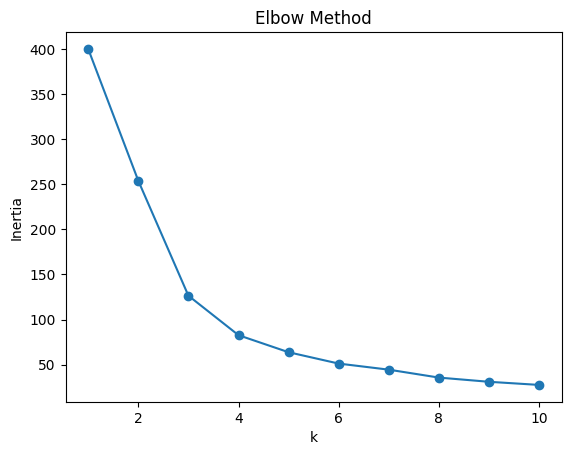

In [34]:
plt.plot(range(1,11), intertia, marker = "o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

#### c)	Apply Silhouette Score for k = 2 to 8. Print the best k and its score.

In [36]:
ss = []
for k in range(2,11):
    sil_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("algo", KMeans(n_clusters= k))
    ])
    labels = sil_pipe.fit_predict(x)
    score = silhouette_score(sil_pipe["preprocessor"].transform(x), labels)
    print(k, score)

2 0.4179724156923368
3 0.5722631382572394
4 0.43847099632854525
5 0.42417580775331365
6 0.47638762518479494
7 0.45913413484846016
8 0.4402511150765086
9 0.4364854080102505
10 0.45658528022540934


#### d)	Fit KMeans with the best k and plot the clusters with centroids using matplotlib.

In [38]:
best_k_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("algo", KMeans(n_clusters= 3))
])
data["Cluster"] = best_k_pipe.fit_predict(x)

<Axes: xlabel='Annual_Income_kUSD', ylabel='Spending_Score'>

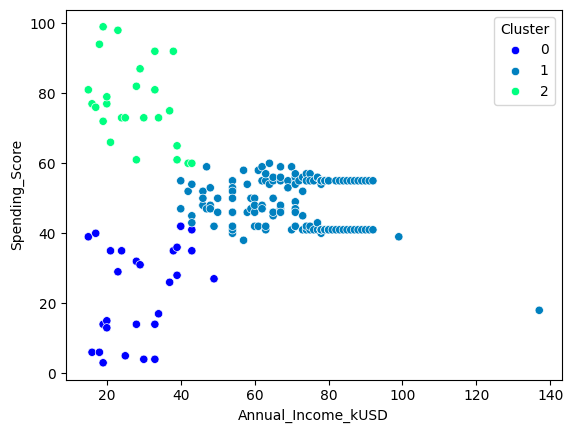

In [41]:
# Visualization of the cluster
sns.scatterplot(data= data, x = "Annual_Income_kUSD", y = "Spending_Score", hue = "Cluster", palette = "winter")

### **Q2.  Using the same dataset, compute Davies-Bouldin Index and Calinski-Harabasz Index for k = 3, 4, 5.**
#### e)	Print all metric values in a formatted comparison table.

In [45]:
for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters= k)
    labels = kmeans.fit_predict(x)

    #computing scores
    db_index = davies_bouldin_score(x, labels)
    ch_index = calinski_harabasz_score(x, labels)

    #printing the results
    print(f"k = {k}")
    print(f"davies_bouldin_score: {db_index}")
    print(f"calinski_harabasz_score: {ch_index}")

k = 3
davies_bouldin_score: 0.638595806340577
calinski_harabasz_score: 213.14364732751827
k = 4
davies_bouldin_score: 0.6711920563443188
calinski_harabasz_score: 278.3124404914857
k = 5
davies_bouldin_score: 0.7890079989175917
calinski_harabasz_score: 273.35960009785964


#### f)	State which k is best and why (2–3 comment lines in your code).

- #### As the above results we can clearly see that k = 3 is best as it give db_score lowest compared to others.

## **Section B — Hierarchical Clustering & DBSCAN**

### **Q3.  Apply Agglomerative Hierarchical Clustering on all numeric features.**
#### g)	Plot the dendrogram using scipy.cluster.hierarchy with ward linkage.

#### h) Cut the dendrogram at an appropriate level and fit AgglomerativeClustering.

#### i)	Visualise clusters using PCA (2D). Compare cluster structure with K-Means result visually.

### **Q4.  Apply DBSCAN on the scaled dataset (Age, Annual Income, Spending Score).**
#### j)	Use a k-distance graph (k=5) to choose a suitable epsilon value.

#### k)	Identify noise points (label = −1). Print their count and percentage.

#### l)	Compare DBSCAN cluster count vs K-Means result. Mention one advantage of DBSCAN.